# Laboratorio 9: AdaBoost y contenedores

**Duración:** 2 horas  
**Formato:** Competencia con contenedores  

---

## Portada del equipo

**Integrantes:**
- Nombre 1 (Usuario GitHub)
- Nombre 2 (Usuario GitHub)
- Nombre 3 (Usuario GitHub)


**Fecha de entrega:**  
__/__/____

## Elemento 1 - Implementación desde cero de AdaBoost

### Elemento 1 - Preguntas teóricas

## Elemento 2 - Comparativa con scikit-learn

### Elemento 2 - Preguntas teóricas

## Elemento 3 - API, contenedor Docker y automatización con Makefile

### Elemento 3 - Preguntas teóricas

## Conclusiones de la práctica

# Laboratorio 9 — Elementos 1 y 2: AdaBoost desde cero y comparativa con `sklearn`

Este cuaderno implementa **Elemento 1** (implementación desde cero de AdaBoost con *decision stumps*) y **Elemento 2** (comparativa con `sklearn.ensemble.AdaBoostClassifier`).

**Dataset**: se utilizará el conjunto `train_set.csv` provisto por la práctica.

**Objetivos**:
1. Implementar una clase `SimpleAdaBoost` con `fit` y `predict`, registrando $\epsilon_t$ y $\alpha_t$.
2. Visualizar la evolución del error/alphas y de los pesos muestrales.
3. Comparar contra `AdaBoostClassifier` de `sklearn` en métricas de clasificación.


In [36]:
# Dependencias
import numpy as np
import pandas as pd
from dataclasses import dataclass, field
from typing import List, Optional, Tuple

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.ensemble import AdaBoostClassifier

import matplotlib.pyplot as plt

# Utilidad de gráficos (no estilos ni colores específicos, conforme a las reglas)
def plot_series(y_values, title, xlabel, ylabel):
    plt.figure()
    plt.plot(range(1, len(y_values)+1), y_values, marker='o')
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(True)
    plt.show()


## Carga de datos y preprocesamiento
Se asume un esquema estilo *Titanic* (variables como `pclass`, `sex`, `age`, `sibsp`, `parch`, `fare`, `embarked`, etc.). Si el archivo contiene nombres distintos, ajusta las listas de columnas abajo.

In [37]:
# Cargar dataset
csv_path = "./train_set.csv"
df = pd.read_csv(csv_path)

print("Shape:", df.shape)
df.head()

Shape: (641, 8)


,pclass,sex,age,sibsp,parch,fare,embarked,survived
0,2,male,47.0,0,0,15.0000,S,0
1,3,male,NaN,0,0,8.7125,C,0
2,1,male,NaN,0,0,26.2875,S,1
3,3,male,NaN,1,1,20.5250,S,0
4,3,male,NaN,1,1,15.9000,NaN,1


In [38]:
# Definir columnas (ajusta si tu CSV difiere)
possible_cols = df.columns.str.lower().tolist()
# Intento robusto de mapear nombres sin depender estrictamente del caso
def has(c):
    return c in possible_cols

# Mapeo tentativo tipo Titanic
y_col = None
for cand in ["survived","target","label","y"]:
    if has(cand):
        y_col = df.columns[df.columns.str.lower()==cand][0]
        break

if y_col is None:
    # si no existe, asumimos que la última columna es la etiqueta binaria
    y_col = df.columns[-1]

# Candidatos por nombre
num_candidates = [c for c in df.columns if df[c].dtype.kind in "if"]
cat_candidates = [c for c in df.columns if df[c].dtype.kind not in "if" and c != y_col]

# Si existen columnas con nombres esperados, priorizarlas
expected_num = [k for k in df.columns if k.lower() in ["age","fare","sibsp","parch"]]
expected_cat = [k for k in df.columns if k.lower() in ["sex","embarked","pclass"]]

# Unir con fallback
num_features = list(dict.fromkeys(expected_num + [c for c in num_candidates if c != y_col]))
cat_features = list(dict.fromkeys(expected_cat + [c for c in cat_candidates if c != y_col]))

print("Etiqueta (y):", y_col)
print("Numéricas:", num_features)
print("Categóricas:", cat_features)

X = df.drop(columns=[y_col])
y = df[y_col]

# Convertir y a { -1, +1 } para AdaBoost teórico si viene como {0,1}
y_unique = sorted(pd.unique(y))
if set(y_unique) == {0,1}:
    y_pm = y.replace({0: -1, 1: 1}).to_numpy()
else:
    # Si viene como strings o {1,2}, intentamos binarizar por frecuencia
    if len(y_unique) == 2:
        mapping = {y_unique[0]: -1, y_unique[1]: 1}
        y_pm = y.map(mapping).to_numpy()
    else:
        raise ValueError("El dataset no es binario. AdaBoost básico requiere 2 clases.")


Etiqueta (y): survived
Numéricas: ['age', 'sibsp', 'parch', 'fare', 'pclass']
Categóricas: ['pclass', 'sex', 'embarked']


In [39]:
# Preprocesamiento: imputación + codificación + escalado
numeric_transformer = Pipeline(
    steps=[("imputer", SimpleImputer(strategy="median")),
           ("scaler", StandardScaler())]
)

categorical_transformer = Pipeline(
    steps=[("imputer", SimpleImputer(strategy="most_frequent")),
           ("onehot", OneHotEncoder(handle_unknown="ignore"))]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, [c for c in num_features if c in X.columns]),
        ("cat", categorical_transformer, [c for c in cat_features if c in X.columns]),
    ],
    remainder="drop"
)

# Split
X_train_raw, X_test_raw, y_train_pm, y_test_pm = train_test_split(
    X, y_pm, test_size=0.2, random_state=42, stratify=y_pm
)

# Ajustar preprocesador y transformar
X_train = preprocessor.fit_transform(X_train_raw)
X_test  = preprocessor.transform(X_test_raw)

print("X_train shape:", X_train.shape, "| X_test shape:", X_test.shape)

X_train shape: (512, 13) | X_test shape: (129, 13)


In [51]:
joblib.dump(preprocessor, "preprocessor.pkl")

['preprocessor.pkl']

## Elemento 1 — Implementación desde cero de AdaBoost
Implementamos `SimpleAdaBoost` con *stumps* (`DecisionTreeClassifier(max_depth=1)`).

In [40]:
class SimpleAdaBoost:
    def __init__(self, n_estimators=50, base_estimator=None):
        self.n_estimators = int(n_estimators)
        self.base_estimator = base_estimator if base_estimator is not None else DecisionTreeClassifier(max_depth=1)
        # almacenamientos
        self.estimators_: List[DecisionTreeClassifier] = []
        self.alphas_: List[float] = []
        self.errors_: List[float] = []
        self.sample_weights_history_: List[np.ndarray] = []

    def fit(self, X, y):
        # y se espera en {-1, +1}
        n_samples = X.shape[0]
        # distribución inicial uniforme
        w = np.ones(n_samples) / n_samples
        self.sample_weights_history_.append(w.copy())

        for t in range(self.n_estimators):
            # Clonar el estimador base
            stump = DecisionTreeClassifier(max_depth=1, random_state=42+t)
            stump.fit(X, y, sample_weight=w)

            # Predicciones en {-1, +1}
            pred = stump.predict(X)
            # Error ponderado
            err = np.sum(w * (pred != y)) / np.sum(w)

            # Evitar divisiones por cero o alfa infinitos
            err = np.clip(err, 1e-12, 1 - 1e-12)

            alpha = 0.5 * np.log((1 - err) / err)

            # Actualizar pesos
            w = w * np.exp(-alpha * y * pred)
            # Normalizar
            w = w / np.sum(w)

            # Guardar
            self.estimators_.append(stump)
            self.alphas_.append(alpha)
            self.errors_.append(err)
            self.sample_weights_history_.append(w.copy())

        return self

    def decision_function(self, X):
        # suma ponderada de clasificadores
        if not self.estimators_:
            raise RuntimeError("El modelo no está entrenado.")
        f = np.zeros(X.shape[0])
        for alpha, stump in zip(self.alphas_, self.estimators_):
            f += alpha * stump.predict(X)
        return f

    def predict(self, X):
        f = self.decision_function(X)
        return np.where(f >= 0, 1, -1)

In [41]:
# Entrenamiento del modelo propio
simple_model = SimpleAdaBoost(n_estimators=100)
simple_model.fit(X_train, y_train_pm)

print("Iteraciones:", len(simple_model.alphas_))
print("Primeros 5 alphas:", simple_model.alphas_[:5])
print("Primeros 5 errores:", simple_model.errors_[:5])

Iteraciones: 100
Primeros 5 alphas: [np.float64(0.6422156129971175), np.float64(0.32873339825741166), np.float64(0.16892510588983034), np.float64(0.12461577378246445), np.float64(0.16201515271365563)]
Primeros 5 errores: [np.float64(0.216796875), np.float64(0.34130888993731895), np.float64(0.4163317806573624), np.float64(0.43801265047771976), np.float64(0.41969384677813326)]


In [42]:
import joblib
joblib.dump(simple_model, "model.pkl")

['model.pkl']

### Evolución de $\epsilon_t$ y $\alpha_t$

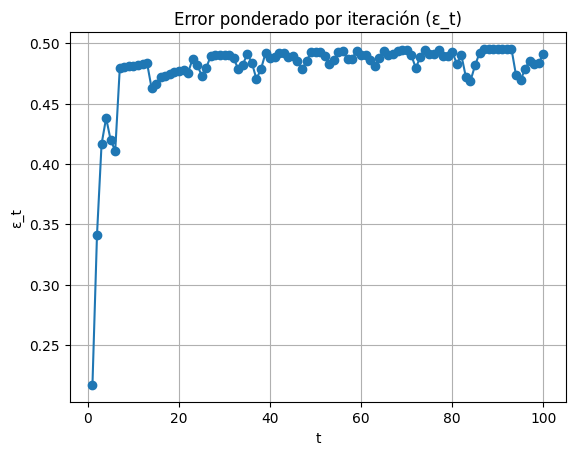

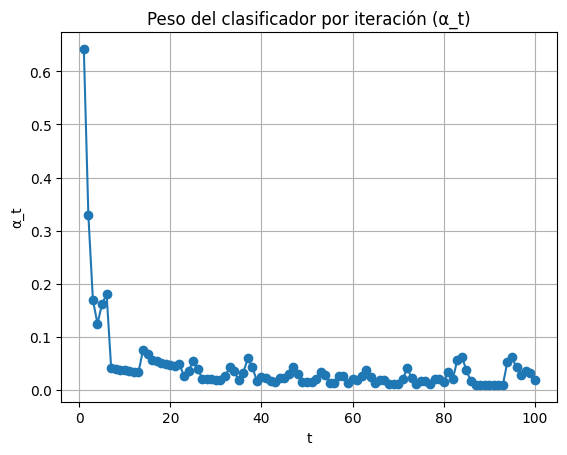

In [43]:
plot_series(simple_model.errors_, "Error ponderado por iteración (ε_t)", "t", "ε_t")
plot_series(simple_model.alphas_, "Peso del clasificador por iteración (α_t)", "t", "α_t")

### Cambios en la distribución de pesos muestrales

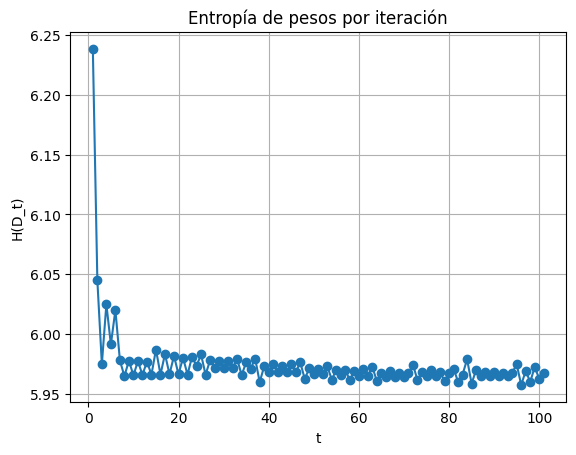

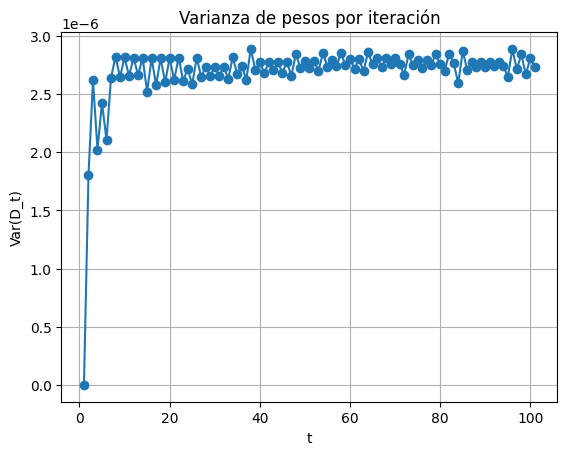

In [44]:
# Visualización simple: varianza de los pesos y entropía aproximada por iteración
def entropy(p):
    p = np.asarray(p, dtype=float)
    p = p[p > 0]
    return -np.sum(p * np.log(p))

entropies = [entropy(w) for w in simple_model.sample_weights_history_]
variances = [np.var(w) for w in simple_model.sample_weights_history_]

plot_series(entropies, "Entropía de pesos por iteración", "t", "H(D_t)")
plot_series(variances, "Varianza de pesos por iteración", "t", "Var(D_t)")

## Métricas en train/test — `SimpleAdaBoost`
Convertimos las predicciones a {0,1} para medir con `sklearn`.

In [45]:
# Predicciones
y_hat_train_pm = simple_model.predict(X_train)
y_hat_test_pm  = simple_model.predict(X_test)

# mapear a {0,1}
to01 = lambda arr: np.where(arr == 1, 1, 0)
y_train = to01(y_train_pm)
y_test  = to01(y_test_pm)
y_hat_train = to01(y_hat_train_pm)
y_hat_test  = to01(y_hat_test_pm)

def metrics_report(y_true, y_pred, title):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    print(title)
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-score:  {f1:.4f}\n")

metrics_report(y_train, y_hat_train, "SimpleAdaBoost — Train")
metrics_report(y_test,  y_hat_test,  "SimpleAdaBoost — Test")

SimpleAdaBoost — Train
Accuracy:  0.8145
Precision: 0.7644
Recall:    0.7449
F1-score:  0.7545

SimpleAdaBoost — Test
Accuracy:  0.8062
Precision: 0.7273
Recall:    0.8000
F1-score:  0.7619



## Elemento 2 — Comparativa con `sklearn.ensemble.AdaBoostClassifier`
Entrenamos un `AdaBoostClassifier` con *stumps* y el mismo número de estimadores.

In [46]:
n_estim = len(simple_model.alphas_)

sk_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1, random_state=42),
    n_estimators=n_estim,
    algorithm="SAMME"
)
sk_model.fit(X_train, y_train)

AdaBoostClassifier(algorithm='SAMME',
                   estimator=DecisionTreeClassifier(max_depth=1,
                                                    random_state=42),
                   n_estimators=100)

In [47]:


y_hat_train_sk = sk_model.predict(X_train)
y_hat_test_sk  = sk_model.predict(X_test)

metrics_report(y_train, y_hat_train_sk, "sklearn.AdaBoost — Train")
metrics_report(y_test,  y_hat_test_sk,  "sklearn.AdaBoost — Test")

sklearn.AdaBoost — Train
Accuracy:  0.8145
Precision: 0.7644
Recall:    0.7449
F1-score:  0.7545

sklearn.AdaBoost — Test
Accuracy:  0.8062
Precision: 0.7273
Recall:    0.8000
F1-score:  0.7619



### Error de entrenamiento por iteración — Comparativa

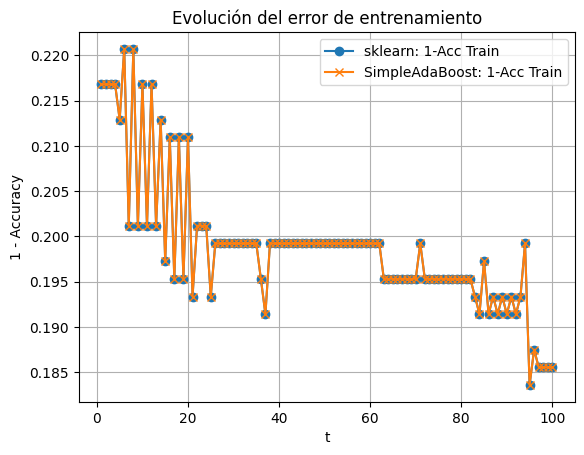

In [48]:
# Estimar error de entrenamiento por iteración en sklearn (usando staged_predict)
sk_train_errors = []
for y_staged in sk_model.staged_predict(X_train):
    sk_train_errors.append(1 - accuracy_score(y_train, y_staged))

our_train_errors = []
running_preds = np.zeros_like(y_train_pm, dtype=float)
for alpha, stump in zip(simple_model.alphas_, simple_model.estimators_):
    running_preds += alpha * stump.predict(X_train)
    y_stage = np.where(running_preds >= 0, 1, -1)
    y_stage01 = np.where(y_stage == 1, 1, 0)
    our_train_errors.append(1 - accuracy_score(y_train, y_stage01))

plt.figure()
plt.plot(range(1, len(sk_train_errors)+1), sk_train_errors, marker='o', label="sklearn: 1-Acc Train")
plt.plot(range(1, len(our_train_errors)+1), our_train_errors, marker='x', label="SimpleAdaBoost: 1-Acc Train")
plt.title("Evolución del error de entrenamiento")
plt.xlabel("t")
plt.ylabel("1 - Accuracy")
plt.grid(True)
plt.legend()
plt.show()

### Fronteras de decisión (proyección PCA 2D)

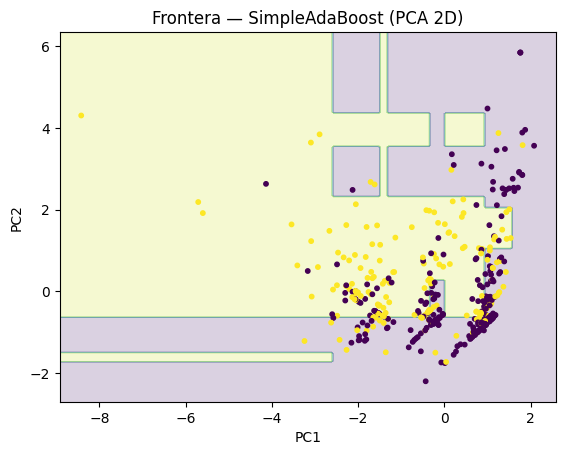

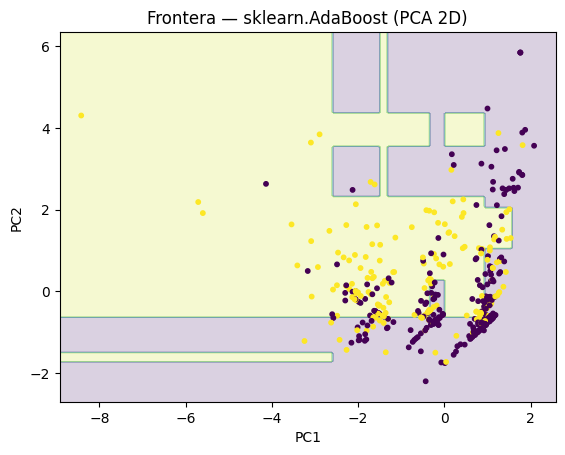

In [49]:
# Para visualizar fronteras, reducimos a 2D con PCA
pca = PCA(n_components=2, random_state=42)
X_train_2d = pca.fit_transform(X_train)
X_test_2d  = pca.transform(X_test)

# Ajustar modelos sobre espacio 2D para sólo visualización (no afecta métricas formales)
simple_vis = SimpleAdaBoost(n_estimators=len(simple_model.alphas_)).fit(X_train_2d, y_train_pm)
sk_vis = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1, random_state=42),
    n_estimators=len(simple_model.alphas_),
    algorithm="SAMME"   
).fit(X_train_2d, y_train)

def plot_decision_boundary(model, X2d, y01, title):
    x_min, x_max = X2d[:,0].min()-0.5, X2d[:,0].max()+0.5
    y_min, y_max = X2d[:,1].min()-0.5, X2d[:,1].max()+0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    grid = np.c_[xx.ravel(), yy.ravel()]
    if isinstance(model, SimpleAdaBoost):
        Z = model.predict(grid)
        Z = np.where(Z==1, 1, 0)
    else:
        Z = model.predict(grid)
    Z = Z.reshape(xx.shape)

    plt.figure()
    plt.contourf(xx, yy, Z, alpha=0.2)
    plt.scatter(X2d[:,0], X2d[:,1], c=y01, s=10)
    plt.title(title)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.show()

y_train01 = y_train
plot_decision_boundary(simple_vis, X_train_2d, y_train01, "Frontera — SimpleAdaBoost (PCA 2D)")
plot_decision_boundary(sk_vis, X_train_2d, y_train01, "Frontera — sklearn.AdaBoost (PCA 2D)")

## Discusión breve
- Ambos modelos comparten la dinámica adaptativa: *stumps* ponderados por $\alpha_t$.
- Diferencias numéricas pueden surgir por tolerancias/criterios internos de `sklearn`.
- A medida que crece `n_estimators`, suele bajar el sesgo; cuidar sobreajuste si hay ruido/outliers.
- La entropía/varianza de pesos muestra cómo el foco del algoritmo se concentra en ejemplos difíciles.

## Artefactos exportables (para Elemento 3 más adelante)
Aunque Elemento 3 (API + Docker + Makefile) no es parte de esta entrega, dejamos preprocesador y modelo entrenado serializados.

In [50]:
import joblib, os

os.makedirs("/mnt/data/model", exist_ok=True)
joblib.dump(preprocessor, "/mnt/data/model/preprocessor.pkl")
joblib.dump(simple_model, "/mnt/data/model/adaboost_simple.pkl")

print("Guardados: /mnt/data/model/preprocessor.pkl, /mnt/data/model/adaboost_simple.pkl")

Guardados: /mnt/data/model/preprocessor.pkl, /mnt/data/model/adaboost_simple.pkl


---
**Fin de Elementos 1 y 2.**

Checklist:
- [x] Implementación `SimpleAdaBoost`.
- [x] Registro de $\epsilon_t$, $\alpha_t$ y análisis de pesos.
- [x] Comparativa con `sklearn` en métricas y curva de error.
- [x] Visualización de fronteras (PCA 2D).
